In [30]:
# 根据静态采集的数据，绘制实际可以工作的工作空间
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [31]:
data = pd.read_csv('../../log/realdata/StaticProcess/11group.csv')

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


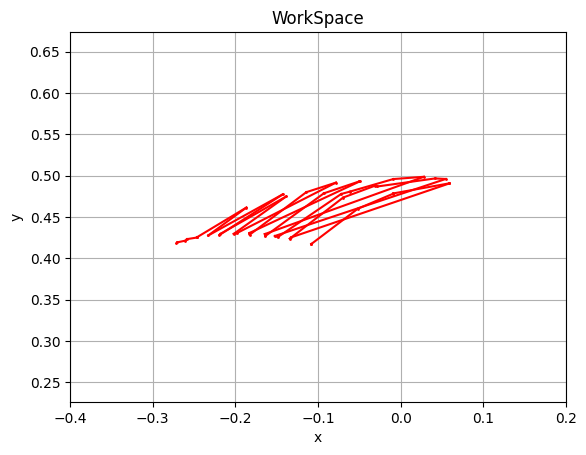

In [32]:
data = data.dropna()
theta_1 = data['theta1']*math.pi/180
theta_2 = data['theta2']*math.pi/180
# 绘制工作空间
plt.figure()
x = 0.25*np.cos(theta_1) + 0.25*np.cos(theta_1+theta_2)
y = 0.25*np.sin(theta_1) + 0.25*np.sin(theta_1+theta_2)
# connect near two point
for i in range(len(x)-1):
    plt.plot([x[i], x[i+1]], [y[i], y[i+1]], 'r-')
plt.plot(x, y, 'ro', markersize=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('WorkSpace')
plt.grid()
plt.axis('equal')
plt.xlim(-0.4, 0.2)
plt.ylim(0.4, 0.5)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


1.4097997906810298 0.9091710470452332
1.3599583301344 0.816467113020755
1.6179009089522318 0.44548914756226776
1.655735657394648 0.5525288497878604
Query Point: [-0.13, 0.43]
Pressure P1: 6.153873691241822
Pressure P2: 2.7282463188213035
Query Point: [-0.09, 0.45]
Pressure P1: 3.757281123127819
Pressure P2: 7.2611504152265525
Query Point: [-0.13, 0.47]
Pressure P1: 19.801130220938756
Pressure P2: 7.519687913683074
Query Point: [-0.17, 0.45]
Pressure P1: 22.67195506725407
Pressure P2: 5.610935564939211


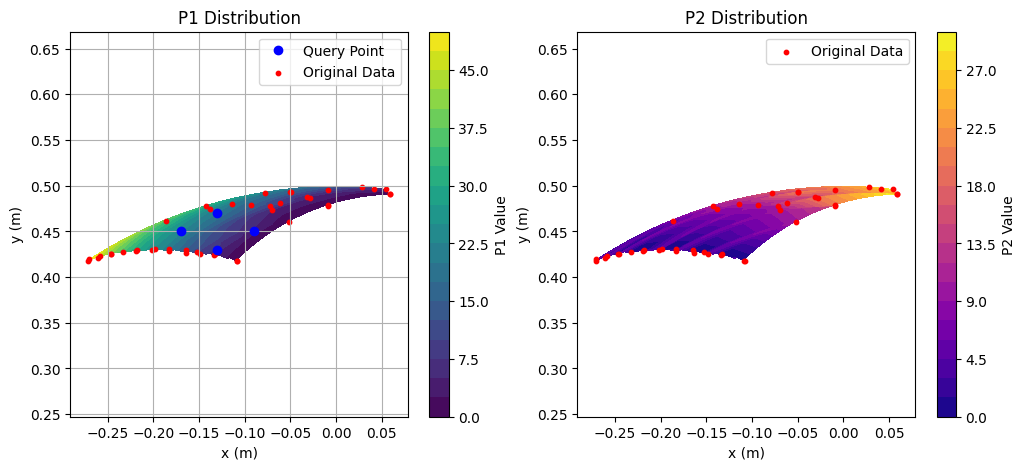

In [45]:
# 为了更好地实验，通过插值找到目标位置对应的气压
from scipy.interpolate import griddata
# 假设轨迹为菱形

# 绘制静力学模型
p1 = data['P1']
p2 = data['P2']

# 扩展插值范围：theta1, theta2, p1, p2
theta1_interp = np.linspace(theta_1.min(), theta_1.max(), 100)
theta2_interp = np.linspace(theta_2.min(), theta_2.max(), 100)

theta1_grid, theta2_grid = np.meshgrid(theta1_interp, theta2_interp)
x_grid = 0.25*np.cos(theta1_grid) + 0.25*np.cos(theta1_grid+theta2_grid)
y_grid = 0.25*np.sin(theta1_grid) + 0.25*np.sin(theta1_grid+theta2_grid)

# 插值计算
P1_interp = griddata((theta_1, theta_2), p1, (theta1_grid, theta2_grid), method='linear')
P2_interp = griddata((theta_1, theta_2), p2, (theta1_grid, theta2_grid), method='linear')

# 绘制热力图 - P1
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)


# query
query_point = [
    [-0.13, 0.43],
    [-0.09, 0.45],
    [-0.13, 0.47],
    [-0.17, 0.45]
]

query_theta1_array = []
query_theta2_array = []
# 逆运动学解算
for query_point_ in query_point:
    _x, _y = query_point_
    # 逆运动学解算
    theta2 = math.acos((_x**2 + _y**2 - 0.25**2 - 0.25**2) / (2*0.25*0.25))
    theta1 = math.acos(_x/math.sqrt(_x**2+_y**2)) - theta2/2
    query_theta1_array.append(theta1)
    query_theta2_array.append(theta2)
    print(theta1, theta2)
query_theta1_array = np.array(query_theta1_array)
query_theta2_array = np.array(query_theta2_array)
query_x_cal = 0.25*np.cos(query_theta1_array) + 0.25*np.cos(query_theta1_array+query_theta2_array)
query_y_cal = 0.25*np.sin(query_theta1_array) + 0.25*np.sin(query_theta1_array+query_theta2_array)

# query_pressure
query_p1 = griddata((theta_1, theta_2), p1, (query_theta1_array, query_theta2_array), method='linear')
query_p2 = griddata((theta_1, theta_2), p2, (query_theta1_array, query_theta2_array), method='linear')
for i in range(len(query_point)):
    print('Query Point:', query_point[i])
    print('Pressure P1:', query_p1[i])
    print('Pressure P2:', query_p2[i])

plt.plot(query_x_cal, query_y_cal, 'bo', label='Query Point')


plt.contourf(x_grid, y_grid, P1_interp, levels=20, cmap='viridis')
plt.colorbar(label='P1 Value')
plt.scatter(x, y, color='red', label='Original Data', s=10)
plt.title('P1 Distribution')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
padding = 0.02  # 额外填充范围
plt.xlim(x.min() - padding, x.max() + padding)
plt.ylim(y.min() - padding, y.max() + padding)
plt.legend()
plt.grid()

# 绘制热力图 - P2
plt.subplot(1, 2, 2)
plt.contourf(x_grid, y_grid, P2_interp, levels=20, cmap='plasma')
plt.colorbar(label='P2 Value')
plt.scatter(x, y, color='red', label='Original Data', s=10)
plt.title('P2 Distribution')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
padding = 0.02  # 额外填充范围
plt.xlim(x.min() - padding, x.max() + padding)
plt.ylim(y.min() - padding, y.max() + padding)
plt.legend()

# plt.tight_layout()
plt.show()
